In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

CUDA available: True
Device: Tesla T4


In [2]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [3]:
import sys
from pathlib import Path

PROJECT = Path("/content/drive/MyDrive/image_realness_project")
sys.path.insert(0, str(PROJECT))

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [4]:
from core.models.joint_model import JointModel

joint_model = JointModel(use_pretrained_backbones=True).to(device)
state = torch.load(PROJECT / "checkpoints" / "JOINT_2024.pth", map_location=device)
joint_model.load_state_dict(state)
joint_model.eval()
print("JOINT loaded")

Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 166MB/s] 


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 150MB/s]


JOINT loaded


In [5]:
# Cell 1 — Setup
import sys
from pathlib import Path
import torch

PROJECT = Path("/content/drive/MyDrive/image_realness_project")
sys.path.insert(0, str(PROJECT))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from core.generation.sd_generator import load_sd_pipeline
from core.models.joint_model import JointModel
from core.guidance.rationality_guidance import RationalityGuidanceScorer
import torchvision.transforms.functional as TF
from PIL import Image

pipe = load_sd_pipeline(project=PROJECT, device=device.type)
pipe.safety_checker = None

joint_model = JointModel(use_pretrained_backbones=True).to(device)
state = torch.load(PROJECT / "checkpoints" / "JOINT_2024.pth", map_location=device)
joint_model.load_state_dict(state)
joint_model.eval()

scorer = RationalityGuidanceScorer(joint_model).to(device)
scorer.eval()
print("Ready")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Ready


In [6]:
# Cell 2 — Load prompts
import pandas as pd

df = pd.read_excel(PROJECT / "external" / "AGIN" / "MSCOCO_prompt.xlsx")
print(df.columns.tolist())
print(df.head())

['id', 'coco_prompt']
   id                                        coco_prompt
0   1               A home computer and chair at a desk.
1   2  A brown bear walking along a river filled with...
2   3       A kitten laying on top of a laptop computer.
3   4  A long car car is green and has wooden accents...
4   5  A large group of people holding their arms out...


In [7]:
# Cell 3 — pick 30 prompts
prompts = df["coco_prompt"].dropna().tolist()[:30]
print(f"{len(prompts)} prompts loaded")

30 prompts loaded


In [8]:
# Cell 4 — run experiment
import subprocess, sys, csv

EXPERIMENT_DIR = PROJECT / "outputs" / "large_scale_experiment"
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

SEED           = 42
NUM_STEPS      = 30
GUIDANCE_SCALE = 7.5
RW             = 0.5
LS             = 10

def score_image(path):
    img = Image.open(path).convert("RGB")
    t = TF.to_tensor(img).unsqueeze(0).to(device).float()
    with torch.no_grad():
        return scorer(t).item()

rows = []

for i, prompt in enumerate(prompts):
    print(f"\n[{i+1}/{len(prompts)}] {prompt[:50]}")
    slug = f"prompt_{i:03d}"
    prompt_dir = EXPERIMENT_DIR / slug
    prompt_dir.mkdir(exist_ok=True)

    # no guidance
    no_guid_path = prompt_dir / "no_guidance.png"
    from core.generation.sd_generator import generate_image
    generate_image(pipe=pipe, prompt=prompt, output_path=no_guid_path,
                   guidance_scale=GUIDANCE_SCALE, num_inference_steps=NUM_STEPS, seed=SEED)
    s_no = score_image(no_guid_path)

    # guided
    guided_dir = prompt_dir / "guided"
    guided_dir.mkdir(exist_ok=True)
    subprocess.run([
        sys.executable,
        str(PROJECT / "scripts" / "generate_with_rationality_guidance_best.py"),
        "--project",             str(PROJECT),
        "--prompt",              prompt,
        "--output-dir",          str(guided_dir),
        "--num-inference-steps", str(NUM_STEPS),
        "--guidance-scale",      str(GUIDANCE_SCALE),
        "--rationality-weight",  str(RW),
        "--guidance-last-steps", str(LS),
        "--seed",                str(SEED),
    ])
    s_guided = score_image(guided_dir / "guided_000.png")

    rows.append({"prompt": prompt, "no_guidance_score": s_no,
                 "guided_score": s_guided, "diff": s_guided - s_no})
    print(f"  no_guidance={s_no:.4f} guided={s_guided:.4f} diff={s_guided-s_no:+.4f}")

# save
results = pd.DataFrame(rows)
results.to_csv(EXPERIMENT_DIR / "results.csv", index=False)
print(f"\nMean improvement: {results['diff'].mean():+.4f}")
print(f"Positive improvements: {(results['diff'] > 0).sum()}/{len(results)}")


[1/30] A home computer and chair at a desk.


  0%|          | 0/30 [00:00<?, ?it/s]

  no_guidance=3.7299 guided=3.8290 diff=+0.0991

[2/30] A brown bear walking along a river filled with roc


  0%|          | 0/30 [00:00<?, ?it/s]

  no_guidance=3.5353 guided=3.6463 diff=+0.1110

[3/30] A kitten laying on top of a laptop computer.


...

  no_guidance=2.7056 guided=2.8135 diff=+0.1079

[29/30] a person on a field flying a kite with trees in th


  0%|          | 0/30 [00:00<?, ?it/s]

  no_guidance=3.4751 guided=3.5597 diff=+0.0845

[30/30] A group of people are preparing to eat pizza.


  0%|          | 0/30 [00:00<?, ?it/s]

  no_guidance=2.9861 guided=3.0682 diff=+0.0822

Mean improvement: +0.1274
Positive improvements: 30/30


In [9]:
# Cell 5 — visualize first 5 prompts
import matplotlib.pyplot as plt

for row in rows[:5]:
    i = rows.index(row)
    slug = f"prompt_{i:03d}"

    img_no  = Image.open(EXPERIMENT_DIR / slug / "no_guidance.png")
    img_guided = Image.open(EXPERIMENT_DIR / slug / "guided" / "guided_000.png")

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_no)
    axes[0].set_title(f"No Guidance\n{row['no_guidance_score']:.4f}", fontsize=9)
    axes[0].axis("off")
    axes[1].imshow(img_guided)
    axes[1].set_title(f"Guided (rw={RW})\n{row['guided_score']:.4f}", fontsize=9)
    axes[1].axis("off")
    plt.suptitle(row['prompt'][:60], fontsize=9)
    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [13]:
# quick inference guidance score check with higher weights
import subprocess, sys
from PIL import Image
import torchvision.transforms.functional as TF

test_prompt = "a crowded market street at night with neon lights and fog"
test_dir = PROJECT / "outputs" / "weight_check"
test_dir.mkdir(exist_ok=True)

from core.generation.sd_generator import generate_image
no_guid_path = test_dir / "no_guidance.png"
generate_image(pipe=pipe, prompt=test_prompt, output_path=no_guid_path,
               guidance_scale=7.5, num_inference_steps=30, seed=42)

def score_pil_path(path):
    img = Image.open(path).convert("RGB")
    t = TF.to_tensor(img).unsqueeze(0).to(device).float()
    with torch.no_grad():
        return scorer(t).item()

print(f"No guidance: {score_pil_path(no_guid_path):.4f}")

for rw in [0.5, 1.0, 2.0, 5.0]:
    out_dir = test_dir / f"rw{rw}"
    out_dir.mkdir(exist_ok=True)
    subprocess.run([
        sys.executable,
        str(PROJECT / "scripts" / "generate_with_rationality_guidance_best.py"),
        "--project",             str(PROJECT),
        "--prompt",              test_prompt,
        "--output-dir",          str(out_dir),
        "--num-inference-steps", "30",
        "--guidance-scale",      "7.5",
        "--rationality-weight",  str(rw),
        "--guidance-last-steps", "10",
        "--seed",                "42",
    ])
    print(f"rw={rw}: {score_pil_path(out_dir / 'guided_000.png'):.4f}")

  0%|          | 0/30 [00:00<?, ?it/s]

No guidance: 2.6550
rw=0.5: 2.7549
rw=1.0: 2.8593
rw=2.0: 3.0934
rw=5.0: 3.7928


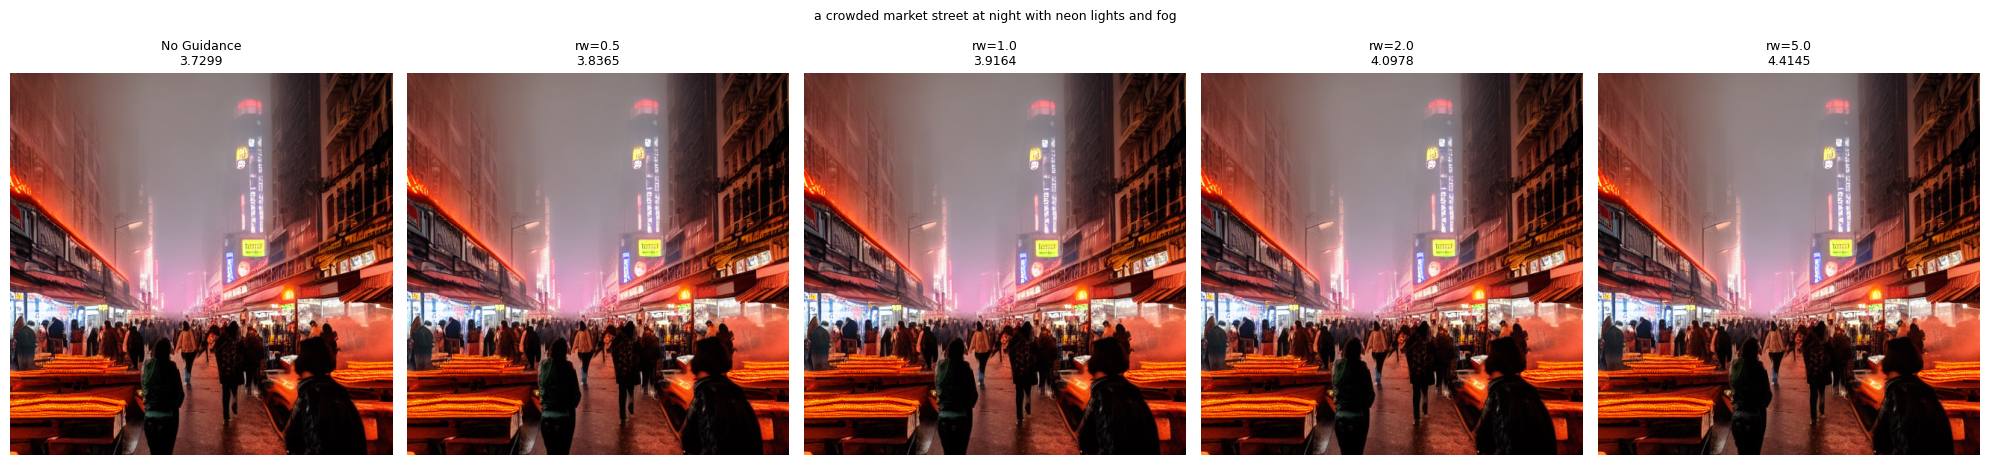

In [14]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

imgs = [
    ("No Guidance\n3.7299", test_dir / "no_guidance.png"),
    ("rw=0.5\n3.8365",      test_dir / "rw0.5" / "guided_000.png"),
    ("rw=1.0\n3.9164",      test_dir / "rw1.0" / "guided_000.png"),
    ("rw=2.0\n4.0978",      test_dir / "rw2.0" / "guided_000.png"),
    ("rw=5.0\n4.4145",      test_dir / "rw5.0" / "guided_000.png"),
]

for ax, (title, path) in zip(axes, imgs):
    ax.imshow(Image.open(path))
    ax.set_title(title, fontsize=9)
    ax.axis("off")

plt.suptitle(test_prompt[:60], fontsize=9)
plt.tight_layout()
plt.show()